In [2]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 1. ルートフォルダを定義
root_folder = "../mydata/00_copy"

# 2. PNGファイルのリストを取得
png_files = []
for dirpath, dirnames, filenames in os.walk(root_folder):
    for filename in filenames:
        if filename.endswith(".png"):
            file_path = os.path.join(dirpath, filename)
            relative_path = os.path.relpath(file_path, start=os.getcwd())
            parent_folder = os.path.basename(dirpath)
            png_files.append((file_path, relative_path, parent_folder))

# 3. 画像処理関数
def process_image(file_info):
    file_path, relative_path, parent_folder = file_info
    try:
        image = cv2.imread(file_path)
        if image is not None:
            height, width = image.shape[:2]
            # アスペクト比を計算
            aspect_ratio = round(width / height, 3) if height > 0 else None
        else:
            raise ValueError("Image data is None")
    except Exception as e:
        print(f"Error reading image: {file_path}\n{e}")
        # 問題があるファイルは削除
        try:
            os.remove(file_path)
            print(f"Deleted invalid file: {file_path}")
        except Exception as delete_error:
            print(f"Error deleting file: {file_path}\n{delete_error}")
        return None
    
    return {
        "path": relative_path,
        "parent": parent_folder,
        "filename": os.path.basename(file_path),
        "original_width": width,
        "original_height": height,
        "aspect_ratio": aspect_ratio
    }

# 4. 並列処理で画像を処理
data = []
with ThreadPoolExecutor() as executor:
    # tqdmで進捗を表示
    for result in tqdm(executor.map(process_image, png_files), total=len(png_files), desc="Processing images"):
        if result is not None:  # 結果がNoneでない場合のみデータを追加
            data.append(result)

# 5. DataFrameに変換
df = pd.DataFrame(data)

# 6. Parquetファイルに保存
output_path = "./re-all.parquet"
df.to_parquet(output_path, index=False)

print(f"一覧表が作成されました: {output_path}")


Processing images: 100%|██████████████████████████████████████| 13971/13971 [01:08<00:00, 203.20it/s]


一覧表が作成されました: ./re-all.parquet


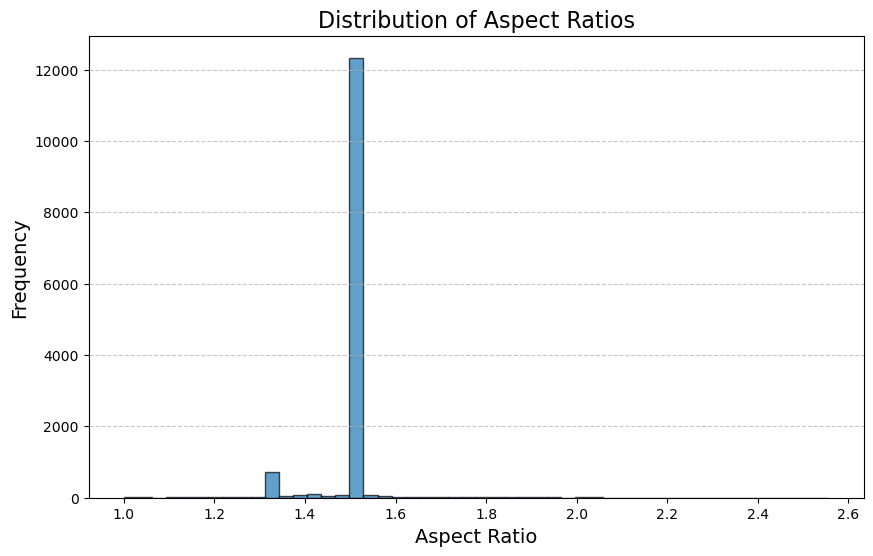

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Parquetファイルを読み込む
df = pd.read_parquet("./re-all.parquet")

# aspect_ratio 列が存在しているか確認
if 'aspect_ratio' in df.columns:
    # aspect_ratio のヒストグラムを作成
    plt.figure(figsize=(10, 6))
    plt.hist(df['aspect_ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Aspect Ratios", fontsize=16)
    plt.xlabel("Aspect Ratio", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("The 'aspect_ratio' column does not exist in the DataFrame.")


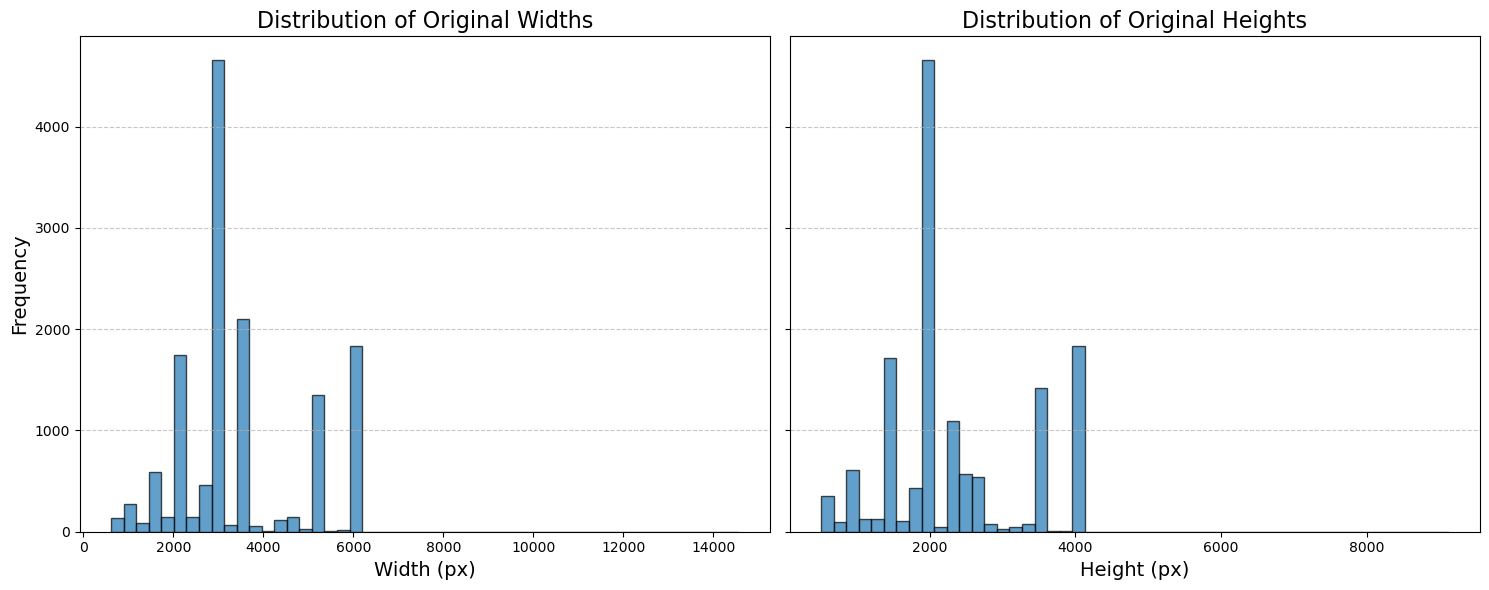

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Parquetファイルを再読み込み
df = pd.read_parquet("./re-all.parquet")

# original_width と original_height のヒストグラムを作成
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# original_width のヒストグラム
axes[0].hist(df['original_width'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title("Distribution of Original Widths", fontsize=16)
axes[0].set_xlabel("Width (px)", fontsize=14)
axes[0].set_ylabel("Frequency", fontsize=14)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# original_height のヒストグラム
axes[1].hist(df['original_height'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title("Distribution of Original Heights", fontsize=16)
axes[1].set_xlabel("Height (px)", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [6]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# path列からファイルパスを取得
paths = df['path'].tolist()

# 画像縮小の処理関数
def resize_image(file_path):
    try:
        # OpenCVで画像をロード
        image = cv2.imread(file_path)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        
        # 画像の幅と高さを取得
        height, width = image.shape[:2]
        
        # 幅が2048pxを超える場合のみ縮小
        if width > 2048:
            # 縮小率を計算
            scale = 2048 / width
            new_width = 2048
            new_height = int(height * scale)
            
            # 画像をリサイズ
            resized_image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
            
            # 元のファイル名で上書き保存
            cv2.imwrite(file_path, resized_image, [cv2.IMWRITE_PNG_COMPRESSION, 3])
            return f"Resized and saved: {file_path}"
        else:
            return f"No resizing needed: {file_path}"
    except Exception as e:
        return f"Error processing {file_path}: {e}"

# 並列処理で画像を縮小
results = []
with ThreadPoolExecutor() as executor:
    for result in tqdm(executor.map(resize_image, paths), total=len(paths), desc="Resizing images"):
        results.append(result)

# 結果を表示
print("\n".join(results))

Resizing images: 100%|█████████████████████████████████████████| 13971/13971 [05:54<00:00, 39.39it/s]

Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_008.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_000.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_001.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_003.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_002.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_006.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_007.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_005.png
Resized and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_004.png
Resized and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_006.png
Resized and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_004.png
Resized and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_005.png
Resized and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_001.png
Resized and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_000.png
Resize

In [8]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# path列からファイルパスを取得
paths = df['path'].tolist()

# 縦横比を1.5に調整する処理関数
def adjust_aspect_ratio(file_path):
    try:
        # OpenCVで画像をロード
        image = cv2.imread(file_path)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        
        # 画像の幅と高さを取得
        height, width = image.shape[:2]

        # 現在の縦横比を計算
        aspect_ratio = width / height

        # 縦横比が1.5ではない場合にパディングを追加
        if aspect_ratio != 1.5:
            target_height = int(width / 1.5)
            
            # 必要なパディング量を計算 (負数を防ぐために max(0, ...) を使用)
            top_padding = max(0, (target_height - height) // 2)
            bottom_padding = max(0, target_height - height - top_padding)
            
            # パディングを適用 (黒で埋める)
            padded_image = cv2.copyMakeBorder(
                image,
                top=top_padding,
                bottom=bottom_padding,
                left=0,
                right=0,
                borderType=cv2.BORDER_CONSTANT,
                value=[0, 0, 0]
            )

            # 同名で保存
            cv2.imwrite(file_path, padded_image, [cv2.IMWRITE_PNG_COMPRESSION, 3])
            return f"Adjusted and saved: {file_path}"
        else:
            return f"No adjustment needed: {file_path}"
    except Exception as e:
        return f"Error processing {file_path}: {e}"

# 並列処理で画像を調整
results = []
with ThreadPoolExecutor() as executor:
    for result in tqdm(executor.map(adjust_aspect_ratio, paths), total=len(paths), desc="Adjusting aspect ratio"):
        results.append(result)

# 結果を表示
print("\n".join(results))

Adjusting aspect ratio: 100%|██████████████████████████████████| 13971/13971 [04:24<00:00, 52.90it/s]

Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_008.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_000.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_001.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_003.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_002.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_006.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_007.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_005.png
Adjusted and saved: ../mydata/00_copy/oVzdeFmLbZXp/oVzdeFmLbZXp_004.png
Adjusted and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_006.png
Adjusted and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_004.png
Adjusted and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_005.png
Adjusted and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_001.png
Adjusted and saved: ../mydata/00_copy/X6wgpw1gc4BA/X6wgpw1gc4BA_

In [9]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# path列からファイルパスを取得
paths = df['path'].tolist()

# 画像サイズを取得する関数
def get_image_size(file_path):
    try:
        # OpenCVで画像をロード
        image = cv2.imread(file_path)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        
        # 幅と高さを取得
        height, width = image.shape[:2]
        # 縦横比を計算
        aspect_ratio = round(width / height, 3) if height > 0 else None
        return file_path, width, height, aspect_ratio
    except Exception as e:
        return file_path, None, None, None

# 並列処理でサイズ情報を取得
results = []
with ThreadPoolExecutor() as executor:
    for result in tqdm(executor.map(get_image_size, paths), total=len(paths), desc="Fetching image sizes"):
        results.append(result)

# 結果をデータフレームに変換
size_df = pd.DataFrame(results, columns=['path', 'current_width', 'current_height', 'current_aspect_ratio'])

# 元のデータフレームとマージ
df = df.merge(size_df, on='path', how='left')

# Parquetファイルに上書き保存
output_path = "./re-all.parquet"
df.to_parquet(output_path, index=False)

print(f"現在の画像サイズ情報を追加し、上書き保存しました: {output_path}")

Fetching image sizes: 100%|███████████████████████████████████| 13971/13971 [00:35<00:00, 391.64it/s]

現在の画像サイズ情報を追加し、上書き保存しました: ./re-all.parquet


In [15]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import mahotas

# 1. Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# 2. 画像をロード
def load_image(file_path):
    try:
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        return image
    except Exception as e:
        print(f"Error loading image {file_path}: {e}")
        return None

# 3. 画像のリサイズとゼロパディング
def resize_image(image):
    try:
        height, width = image.shape[:2]
        aspect_ratio = width / height
        if aspect_ratio != 1.5:
            target_width = max(width, int(height * 1.5))
            target_height = max(height, int(width / 1.5))
            top_padding = max(0, (target_height - height) // 2)
            bottom_padding = max(0, target_height - height - top_padding)
            left_padding = max(0, (target_width - width) // 2)
            right_padding = max(0, target_width - width - left_padding)
            image = cv2.copyMakeBorder(
                image,
                top=top_padding,
                bottom=bottom_padding,
                left=left_padding,
                right=right_padding,
                borderType=cv2.BORDER_CONSTANT,
                value=[0]
            )
        resized_image = cv2.resize(image, (300, 200), interpolation=cv2.INTER_AREA)
        return resized_image
    except Exception as e:
        print(f"Error resizing image: {e}")
        return None

# 4. Cannyエッジ検出
def apply_canny(image, threshold1=50, threshold2=150):
    try:
        edges = cv2.Canny(image, threshold1, threshold2)
        return edges
    except Exception as e:
        print(f"Error applying Canny edge detection: {e}")
        return None

# 5. Zernikeモーメント計算
def calculate_zernike(image, radius=100):
    try:
        zernike_moments = mahotas.features.zernike_moments(image, radius)
        return np.array(zernike_moments)
    except Exception as e:
        print(f"Error calculating Zernike moments: {e}")
        return None

# 6. 画像を処理（ロード→リサイズ→エッジ検出→Zernike計算）
def process_image(file_path):
    try:
        image = load_image(file_path)
        if image is None:
            return None

        resized_image = resize_image(image)
        if resized_image is None:
            return None

        edges = apply_canny(resized_image)
        if edges is None:
            return None

        zernike = calculate_zernike(edges)
        return zernike
    except Exception as e:
        print(f"Error processing image {file_path}: {e}")
        return None

# 7. 特徴量を抽出（並列処理）
def extract_features(paths):
    with ThreadPoolExecutor() as executor:
        zernike_features = list(tqdm(executor.map(process_image, paths), total=len(paths), desc="Processing images"))
    return zernike_features

# 8. データフレームに特徴量を追加
df['zernike'] = extract_features(df['path'])

# 9. Zernike特徴量の次元チェック
zernike_lengths = [len(z) for z in df['zernike'] if z is not None]
if len(set(zernike_lengths)) == 1:
    print(f"All Zernike feature vectors have the same length: {zernike_lengths[0]}")
else:
    print("Zernike feature vectors have inconsistent dimensions!")

# 10. Parquetファイルを上書き保存
df.to_parquet("./re-all.parquet", index=False)
print("Features extracted and saved to re-all.parquet.")


Processing images: 100%|██████████████████████████████████████| 13971/13971 [00:55<00:00, 251.14it/s]


All Zernike feature vectors have the same length: 25
Features extracted and saved to re-all.parquet.


In [17]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 1. Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# 2. 画像をロード
def load_image(file_path):
    try:
        image = cv2.imread(file_path)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        return image
    except Exception as e:
        print(f"Error loading image {file_path}: {e}")
        return None

# 3. 画像のリサイズとゼロパディング（カラーヒストグラムではRGB画像のまま扱う）
def resize_image(image):
    try:
        height, width = image.shape[:2]
        aspect_ratio = width / height
        if aspect_ratio != 1.5:
            target_width = max(width, int(height * 1.5))
            target_height = max(height, int(width / 1.5))
            top_padding = max(0, (target_height - height) // 2)
            bottom_padding = max(0, target_height - height - top_padding)
            left_padding = max(0, (target_width - width) // 2)
            right_padding = max(0, target_width - width - left_padding)
            image = cv2.copyMakeBorder(
                image,
                top=top_padding,
                bottom=bottom_padding,
                left=left_padding,
                right=right_padding,
                borderType=cv2.BORDER_CONSTANT,
                value=[0, 0, 0]  # 黒でパディング（カラー画像なので3チャンネル）
            )
        resized_image = cv2.resize(image, (300, 200), interpolation=cv2.INTER_AREA)
        return resized_image
    except Exception as e:
        print(f"Error resizing image: {e}")
        return None

# 4. カラーヒストグラム計算
def calculate_color_histogram(image, bins=256):
    try:
        # 各チャンネルのヒストグラムを計算
        hist_r = cv2.calcHist([image], [0], None, [bins], [0, 256]).flatten()
        hist_g = cv2.calcHist([image], [1], None, [bins], [0, 256]).flatten()
        hist_b = cv2.calcHist([image], [2], None, [bins], [0, 256]).flatten()

        # 正規化（オプション: 必要であればコメントアウト）
        hist_r /= hist_r.sum()
        hist_g /= hist_g.sum()
        hist_b /= hist_b.sum()

        # ヒストグラムを結合して1つのベクトルとして返す
        return np.concatenate([hist_r, hist_g, hist_b])
    except Exception as e:
        print(f"Error calculating color histogram: {e}")
        return None

# 5. 各画像を処理（ロード→リサイズ→カラーヒストグラム計算）
def process_image(file_path):
    try:
        image = load_image(file_path)
        if image is None:
            return None

        resized_image = resize_image(image)
        if resized_image is None:
            return None

        color_histogram = calculate_color_histogram(resized_image)
        return color_histogram
    except Exception as e:
        print(f"Error processing image {file_path}: {e}")
        return None

# 6. 特徴量を抽出（並列処理）
def extract_color_histograms(paths):
    with ThreadPoolExecutor() as executor:
        histograms = list(tqdm(executor.map(process_image, paths), total=len(paths), desc="Processing images"))
    return histograms

# 7. データフレームに特徴量を追加
df['RGB_Histogram'] = extract_color_histograms(df['path'])

# 8. Parquetファイルを上書き保存
df.to_parquet("./re-all.parquet", index=False)
print("Color histograms extracted and saved to re-all.parquet.")


Processing images: 100%|██████████████████████████████████████| 13971/13971 [00:50<00:00, 274.04it/s]


Color histograms extracted and saved to re-all.parquet.


In [18]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# 1. Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# 2. 画像をロード
def load_image(file_path):
    try:
        image = cv2.imread(file_path)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        return image
    except Exception as e:
        print(f"Error loading image {file_path}: {e}")
        return None

# 3. 画像のリサイズとゼロパディング
def resize_image(image):
    try:
        height, width = image.shape[:2]
        aspect_ratio = width / height
        if aspect_ratio != 1.5:
            target_width = max(width, int(height * 1.5))
            target_height = max(height, int(width / 1.5))
            top_padding = max(0, (target_height - height) // 2)
            bottom_padding = max(0, target_height - height - top_padding)
            left_padding = max(0, (target_width - width) // 2)
            right_padding = max(0, target_width - width - left_padding)
            image = cv2.copyMakeBorder(
                image,
                top=top_padding,
                bottom=bottom_padding,
                left=left_padding,
                right=right_padding,
                borderType=cv2.BORDER_CONSTANT,
                value=[0, 0, 0]
            )
        resized_image = cv2.resize(image, (300, 200), interpolation=cv2.INTER_AREA)
        return resized_image
    except Exception as e:
        print(f"Error resizing image: {e}")
        return None

# 4. HSVヒストグラム計算
def calculate_hsv_histogram(image, bins=256):
    try:
        # RGBをHSVに変換
        hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        # 各チャンネル（H, S, V）のヒストグラムを計算
        hist_h = cv2.calcHist([hsv_image], [0], None, [bins], [0, 180]).flatten()  # Hue: 0-180
        hist_s = cv2.calcHist([hsv_image], [1], None, [bins], [0, 256]).flatten()  # Saturation: 0-256
        hist_v = cv2.calcHist([hsv_image], [2], None, [bins], [0, 256]).flatten()  # Value: 0-256

        # 正規化（オプション: 必要であればコメントアウト）
        hist_h /= hist_h.sum()
        hist_s /= hist_s.sum()
        hist_v /= hist_v.sum()

        # ヒストグラムを結合して1つのベクトルとして返す
        return np.concatenate([hist_h, hist_s, hist_v])
    except Exception as e:
        print(f"Error calculating HSV histogram: {e}")
        return None

# 5. 各画像を処理（ロード→リサイズ→HSVヒストグラム計算）
def process_image(file_path):
    try:
        image = load_image(file_path)
        if image is None:
            return None

        resized_image = resize_image(image)
        if resized_image is None:
            return None

        hsv_histogram = calculate_hsv_histogram(resized_image)
        return hsv_histogram
    except Exception as e:
        print(f"Error processing image {file_path}: {e}")
        return None

# 6. 特徴量を抽出（並列処理）
def extract_hsv_histograms(paths):
    with ThreadPoolExecutor() as executor:
        histograms = list(tqdm(executor.map(process_image, paths), total=len(paths), desc="Processing images"))
    return histograms

# 7. データフレームに特徴量を追加
df['HSV_Histogram'] = extract_hsv_histograms(df['path'])

# 8. Parquetファイルを上書き保存
df.to_parquet("./re-all.parquet", index=False)
print("HSV histograms extracted and saved to re-all.parquet.")


Processing images: 100%|██████████████████████████████████████| 13971/13971 [00:51<00:00, 269.44it/s]


HSV histograms extracted and saved to re-all.parquet.


In [23]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# 画像をロード
def load_image(file_path):
    try:
        image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Image could not be read: {file_path}")
        return image
    except Exception as e:
        print(f"Error loading image {file_path}: {e}")
        return None

# 画像のリサイズとゼロパディング
def resize_image(image):
    try:
        height, width = image.shape[:2]
        aspect_ratio = width / height
        if aspect_ratio != 1.5:
            target_width = max(width, int(height * 1.5))
            target_height = max(height, int(width / 1.5))
            top_padding = max(0, (target_height - height) // 2)
            bottom_padding = max(0, target_height - height - top_padding)
            left_padding = max(0, (target_width - width) // 2)
            right_padding = max(0, target_width - width - left_padding)
            image = cv2.copyMakeBorder(
                image,
                top=top_padding,
                bottom=bottom_padding,
                left=left_padding,
                right=right_padding,
                borderType=cv2.BORDER_CONSTANT,
                value=[0]
            )
        resized_image = cv2.resize(image, (300, 200), interpolation=cv2.INTER_AREA)
        return resized_image
    except Exception as e:
        print(f"Error resizing image: {e}")
        return None

# ORB特徴量の計算
def calculate_orb_features(image, nfeatures=500):
    try:
        orb = cv2.ORB_create(nfeatures=nfeatures)
        keypoints, descriptors = orb.detectAndCompute(image, None)
        if descriptors is None:
            return np.zeros(nfeatures * 32, dtype=np.uint8)  # ゼロ埋めで固定長ベクトルを返す
        # 固定長ベクトルに変換
        if len(descriptors) < nfeatures:
            padded = np.zeros((nfeatures, 32), dtype=np.uint8)
            padded[:len(descriptors)] = descriptors
            return padded.flatten()
        return descriptors[:nfeatures].flatten()
    except Exception as e:
        print(f"Error calculating ORB features: {e}")
        return None

# 各画像を処理
def process_image(file_path):
    try:
        image = load_image(file_path)
        if image is None:
            return None

        resized_image = resize_image(image)
        if resized_image is None:
            return None

        orb_features = calculate_orb_features(resized_image)
        return orb_features
    except Exception as e:
        print(f"Error processing image {file_path}: {e}")
        return None

# 特徴量を抽出（並列処理）
def extract_orb_features(paths):
    with ThreadPoolExecutor() as executor:
        orb_features = list(tqdm(executor.map(process_image, paths), total=len(paths), desc="Processing images"))
    return orb_features

# データフレームに特徴量を追加
df['orb'] = extract_orb_features(df['path'])

# Parquetファイルを上書き保存
df.to_parquet("./re-all.parquet", index=False)
print("ORB features extracted and saved to re-all.parquet.")

Processing images: 100%|██████████████████████████████████████| 13971/13971 [00:49<00:00, 284.43it/s]


ORB features extracted and saved to re-all.parquet.


In [24]:
# Parquetファイルをロード
df = pd.read_parquet("./re-all.parquet")

# 各列のベクトルの次元を確認する関数
def check_vector_dimensions(column_name):
    lengths = [len(vec) for vec in df[column_name] if vec is not None]
    unique_lengths = set(lengths)
    if len(unique_lengths) == 1:
        print(f"All vectors in column '{column_name}' have the same length: {list(unique_lengths)[0]}")
    else:
        print(f"Vectors in column '{column_name}' have inconsistent dimensions: {unique_lengths}")

# orb列の次元チェック
check_vector_dimensions('orb')

All vectors in column 'orb' have the same length: 16000
